# 05 — Model Audit
This notebook performs a comprehensive audit on the Hurdle Model (Stage 1 & Stage 2). It covers:
- Discrimination & Calibration (Classification)
- Residuals & Overall Fit (Regression)
- Temporal Drift
- Subgroup Fairness
- SHAP Interpretability
- RNA Paradox Statistical Analysis

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    mean_squared_error,
)

sys.path.append('../')
from src.data_prep import bootstrap_ci, permutation_test
from src.evaluation import (
    classification_discrimination, confusion_at_threshold, threshold_sweep,
    calibration_curve_data, expected_calibration_error,
    regression_metrics, residual_diagnostics, temporal_drift,
    plot_calibration, plot_residuals,
)
from src.audit import fairness_slice, slice_disparities, top_bottom_slices

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

FIGURES_DIR = "../outputs/figures/audit"
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{name}.pdf", bbox_inches='tight')
    plt.savefig(f"{FIGURES_DIR}/{name}.png", dpi=150, bbox_inches='tight')

MODELS = ["rf", "xgb", "lgbm", "cb", "stacking"]
COLORS = dict(zip(MODELS, sns.color_palette("tab10", len(MODELS))))

In [2]:
# Load IDs and threshold
with open("best_run_ids.json", "r") as f:
    best_runs = json.load(f)
thr_youden = best_runs["threshold_youden"]
clf_run_id = best_runs["stage1_classification"]
reg_run_id = best_runs["stage2_regression"]
# In case we need RF run IDs specifically
mlflow.set_tracking_uri("./mlruns")
client = mlflow.tracking.MlflowClient()


/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [3]:
# Load exports from 04_Modeling
clf_preds = pd.read_parquet("../outputs/analyses/audit_clf_predictions.parquet")
reg_preds = pd.read_parquet("../outputs/analyses/audit_reg_predictions.parquet")
univ_preds = pd.read_parquet("../outputs/analyses/audit_universe_predictions.parquet")
print("Classification exports:", clf_preds.shape)
print("Regression exports:", reg_preds.shape)
print("Universe exports:", univ_preds.shape)

# Context columns needed for slicing (join on sale_year, day, lot)
_ctx_cols = [
    "sale_year", "day", "lot",
    "sex_C", "sex_F", "sex_G", "sex_H", "sex_M",
    "intraday_position", "is_prime_time",
    "sire_frequency", "consignor_frequency",
    "log_year_median_price_prior",
]
ctx = univ_preds[_ctx_cols].copy()
ctx["sex"] = (
    ctx[["sex_C", "sex_F", "sex_G", "sex_H", "sex_M"]]
    .idxmax(axis=1)
    .str.replace("sex_", "", regex=False)
    .replace({"C": "Colt", "F": "Filly", "G": "Gelding", "H": "Horse", "M": "Mare"})
)

# Enrich clf and reg parquets with context
clf = clf_preds.merge(ctx, on=["sale_year", "day", "lot"], how="left")
reg = reg_preds.merge(ctx, on=["sale_year", "day", "lot"], how="left")
print(f"\nContext join coverage clf: {clf['sex'].notna().mean():.1%}")
print(f"Context join coverage reg: {reg['sex'].notna().mean():.1%}")

Classification exports: (4694, 9)
Regression exports: (4099, 11)
Universe exports: (19005, 68)

Context join coverage clf: 100.0%
Context join coverage reg: 100.0%


## 1. Stage 1 — Discrimination

AUC-ROC, AUC-PR, Brier score, log-loss for each model over the OOT set (2022–2025).
All CIs are 95% bootstrap (n=2000). Baseline from README §5: AUC-ROC ≥ 0.617.

=== Stage 1: Discrimination (OOT 2022–2025) ===


,AUC-ROC,AUC-PR,Brier,Log-loss
model,,,,
rf,0.6290 [0.6047–0.6517],0.9236 [0.9134–0.9324],0.1719 [0.1693–0.1747],0.5296
xgb,0.5588 [0.5347–0.5828],0.9052 [0.8947–0.9146],0.1179 [0.1113–0.1248],0.4048
lgbm,0.6050 [0.5798–0.6293],0.9137 [0.9030–0.9231],0.1280 [0.1232–0.1332],0.4193
cb,0.5890 [0.5653–0.6116],0.9133 [0.9032–0.9226],0.1252 [0.1211–0.1300],0.4189
stacking,0.6165 [0.5925–0.6396],0.9204 [0.9104–0.9292],0.1045 [0.0976–0.1118],0.3607


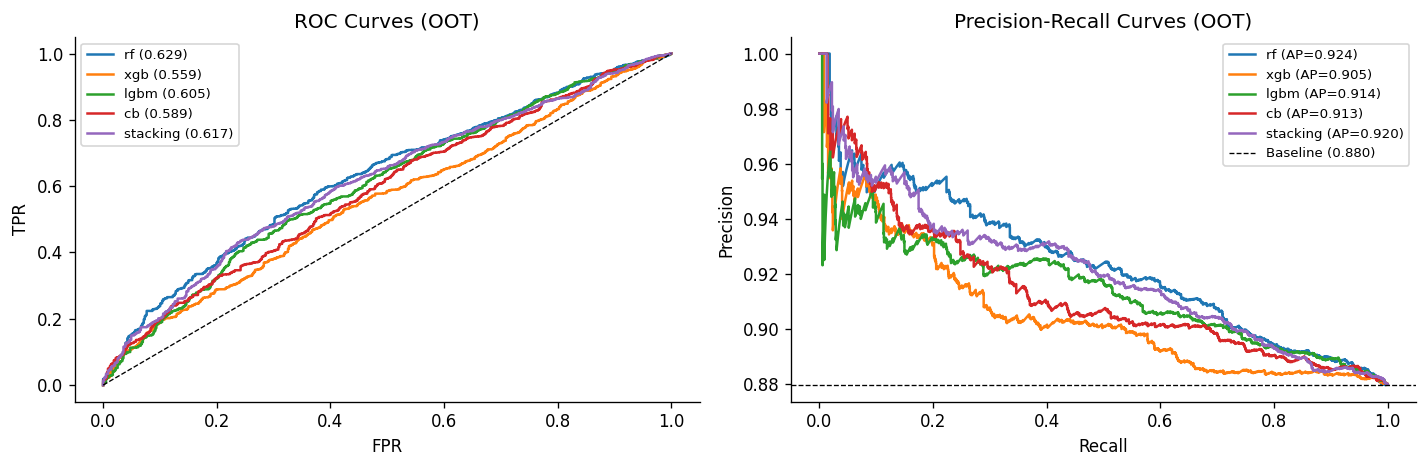

In [4]:
y_true = clf["sold_to_third_party"].values

disc_rows = []
for m in MODELS:
    d = classification_discrimination(y_true, clf[f"prob_{m}"].values)
    disc_rows.append({
        "model": m,
        "AUC-ROC": f"{d['auc_roc']:.4f} [{d.get('auc_roc_ci_lo', np.nan):.4f}–{d.get('auc_roc_ci_hi', np.nan):.4f}]",
        "AUC-PR": f"{d['auc_pr']:.4f} [{d.get('auc_pr_ci_lo', np.nan):.4f}–{d.get('auc_pr_ci_hi', np.nan):.4f}]",
        "Brier": f"{d['brier']:.4f} [{d.get('brier_ci_lo', np.nan):.4f}–{d.get('brier_ci_hi', np.nan):.4f}]",
        "Log-loss": f"{d['log_loss']:.4f}",
    })

disc_df = pd.DataFrame(disc_rows).set_index("model")
print("=== Stage 1: Discrimination (OOT 2022–2025) ===")
display(disc_df)

# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for m in MODELS:
    p_vals = clf[f"prob_{m}"].values
    fpr, tpr, _ = roc_curve(y_true, p_vals)
    auc_val = roc_auc_score(y_true, p_vals)
    axes[0].plot(fpr, tpr, label=f"{m} ({auc_val:.3f})", color=COLORS[m], lw=1.5)

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(title="ROC Curves (OOT)", xlabel="FPR", ylabel="TPR")
axes[0].legend(fontsize=8)

for m in MODELS:
    p_vals = clf[f"prob_{m}"].values
    prec, rec, _ = precision_recall_curve(y_true, p_vals)
    ap = average_precision_score(y_true, p_vals)
    axes[1].plot(rec, prec, label=f"{m} (AP={ap:.3f})", color=COLORS[m], lw=1.5)

axes[1].axhline(y_true.mean(), color="k", ls="--", lw=0.8, label=f"Baseline ({y_true.mean():.3f})")
axes[1].set(title="Precision-Recall Curves (OOT)", xlabel="Recall", ylabel="Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
savefig("01_discrimination_curves")
plt.show()

## 2. Stage 1 — Calibration

Reliability diagram for the stacking ensemble (best model). Quantile bins (n=10).
ECE quantifies overall calibration quality — lower is better.
Note: only post-calibration probabilities are available in the audit parquet.

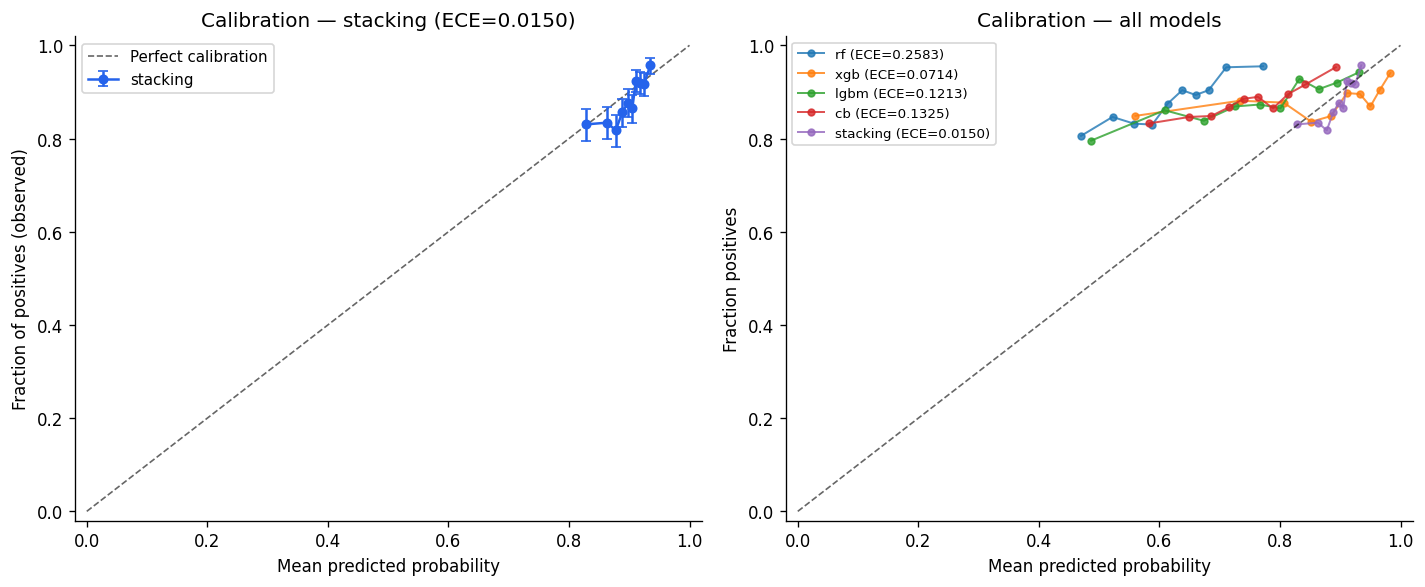

,ECE
model,
stacking,0.01
xgb,0.07
lgbm,0.12
cb,0.13
rf,0.26


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, m in enumerate(MODELS):
    calib = calibration_curve_data(y_true, clf[f"prob_{m}"].values)
    ece = expected_calibration_error(y_true, clf[f"prob_{m}"].values)
    if m == "stacking":
        plot_calibration(calib, ax=axes[0], title=f"Calibration — stacking (ECE={ece:.4f})", label=f"stacking")
    axes[1].plot(
        calib["mean_predicted"], calib["frac_positives"],
        "o-", label=f"{m} (ECE={ece:.4f})", color=COLORS[m], lw=1.2, ms=4, alpha=0.8,
    )

axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
axes[1].set(title="Calibration — all models", xlabel="Mean predicted probability", ylabel="Fraction positives")
axes[1].legend(fontsize=8)
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02)

savefig("02_calibration")
plt.show()

# ECE summary table
ece_rows = [{"model": m, "ECE": round(expected_calibration_error(y_true, clf[f"prob_{m}"].values), 5)} for m in MODELS]
display(pd.DataFrame(ece_rows).set_index("model").sort_values("ECE"))

## 3. Stage 1 — Threshold Analysis

Youden's J fixed threshold: `thr_youden = 0.888` (from 04_Modeling).
Sweep over [0.05, 0.99] to visualize the F1-weighted / Precision / Recall trade-off.

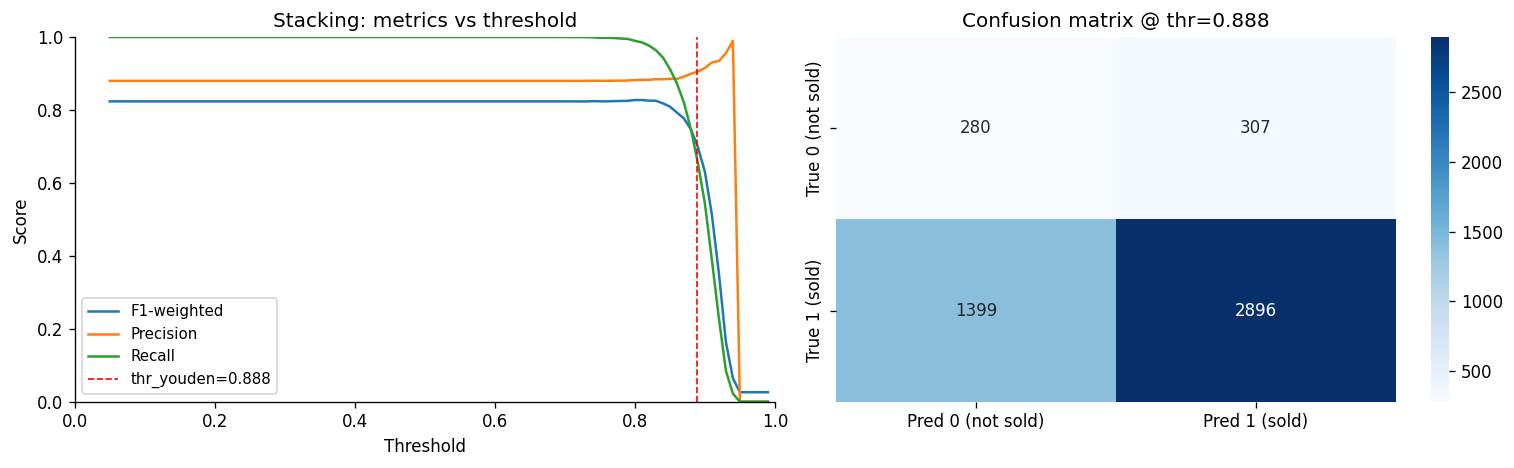


At threshold 0.888:
  precision: 0.9042
  recall: 0.6743
  f1_weighted: 0.7093
  specificity: 0.4770


In [6]:
p_stack = clf["prob_stacking"].values
sweep = threshold_sweep(y_true, p_stack)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(sweep["threshold"], sweep["f1_weighted"], label="F1-weighted", lw=1.5)
ax.plot(sweep["threshold"], sweep["precision"], label="Precision", lw=1.5)
ax.plot(sweep["threshold"], sweep["recall"], label="Recall", lw=1.5)
ax.axvline(thr_youden, color="red", ls="--", lw=1, label=f"thr_youden={thr_youden:.3f}")
ax.set(title="Stacking: metrics vs threshold", xlabel="Threshold", ylabel="Score")
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Confusion matrix at Youden threshold
cm_dict = confusion_at_threshold(y_true, p_stack, thr=thr_youden)
cm_matrix = np.array([[cm_dict["tn"], cm_dict["fp"]], [cm_dict["fn"], cm_dict["tp"]]])
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Pred 0 (not sold)", "Pred 1 (sold)"],
            yticklabels=["True 0 (not sold)", "True 1 (sold)"])
axes[1].set_title(f"Confusion matrix @ thr={thr_youden:.3f}")

savefig("03_threshold_analysis")
plt.show()

print(f"\nAt threshold {thr_youden:.3f}:")
for k in ["precision", "recall", "f1_weighted", "specificity"]:
    print(f"  {k}: {cm_dict[k]:.4f}")

## 4. Stage 2 — Regression Metrics

RMSE, MAE, R², MAPE (log-scale and GNS-scale) for all five models over OOT 2022–2025.
Baseline from README §5: RMSE_log OOT ≈ 1.132.
Note: predictions in the parquet are in raw log-scale (not detrended) — GNS = exp(log_pred).

=== Stage 2: Regression Metrics (OOT 2022–2025) ===


,RMSE_log,MAE_log,R²_log,RMSE_gns,MAE_gns,MAPE_gns,Bias_log
model,,,,,,,
rf,1.1247 [1.1012–1.1487],0.8897,0.2835,"60,586","24,398",125.6%,+0.1461
xgb,1.2722 [1.2448–1.2977],1.0139,0.0832,"61,446","25,788",132.7%,+0.3258
lgbm,1.1548 [1.1309–1.1792],0.9165,0.2446,"59,922","24,607",133.2%,+0.1435
cb,1.1713 [1.1463–1.1951],0.9323,0.2228,"61,062","24,849",121.4%,+0.2463
stacking,1.1484 [1.1245–1.1720],0.9167,0.2530,"61,367","24,792",113.1%,+0.2740


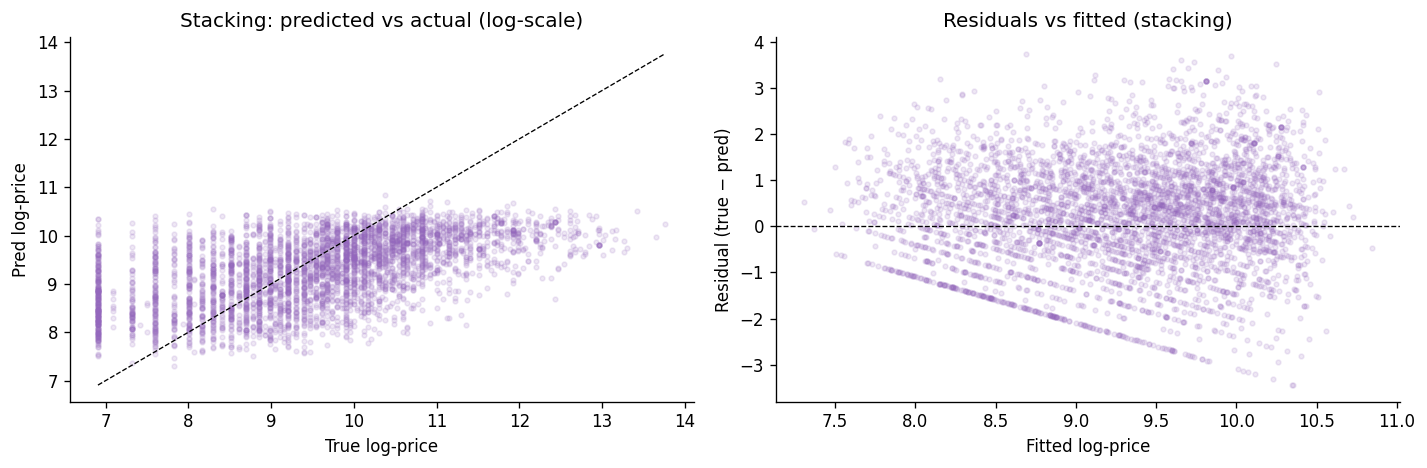

In [7]:
y_reg_true = reg["log_price_true"].values
reg_rows = []

for m in MODELS:
    col = f"log_price_pred_{m}"
    met = regression_metrics(y_reg_true, reg[col].values, gns_scale=True)
    reg_rows.append({
        "model": m,
        "RMSE_log": f"{met['rmse_log']:.4f} [{met['rmse_log_ci_lo']:.4f}–{met['rmse_log_ci_hi']:.4f}]",
        "MAE_log": f"{met['mae_log']:.4f}",
        "R²_log": f"{met['r2_log']:.4f}",
        "RMSE_gns": f"{met['rmse_gns']:,.0f}",
        "MAE_gns": f"{met['mae_gns']:,.0f}",
        "MAPE_gns": f"{met['mape_gns']:.1%}",
        "Bias_log": f"{met['bias_log']:+.4f}",
    })

reg_df = pd.DataFrame(reg_rows).set_index("model")
print("=== Stage 2: Regression Metrics (OOT 2022–2025) ===")
display(reg_df)

# Predicted vs actual scatter for stacking
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_pred_s = reg["log_price_pred_stacking"].values
axes[0].scatter(y_reg_true, y_pred_s, alpha=0.15, s=8, color=COLORS["stacking"])
mn, mx = y_reg_true.min(), y_reg_true.max()
axes[0].plot([mn, mx], [mn, mx], "k--", lw=0.8)
axes[0].set(title="Stacking: predicted vs actual (log-scale)", xlabel="True log-price", ylabel="Pred log-price")

resid_s = y_reg_true - y_pred_s
axes[1].scatter(y_pred_s, resid_s, alpha=0.15, s=8, color=COLORS["stacking"])
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set(title="Residuals vs fitted (stacking)", xlabel="Fitted log-price", ylabel="Residual (true − pred)")

savefig("04_regression_scatter")
plt.show()

## 5. Stage 2 — Residual Diagnostics

Bias (mean residual = true − predicted) by `sale_year`, `day`, `sex`, and intraday position quartile.
A zero-centered bar confirms no systematic over/under-prediction in that segment.

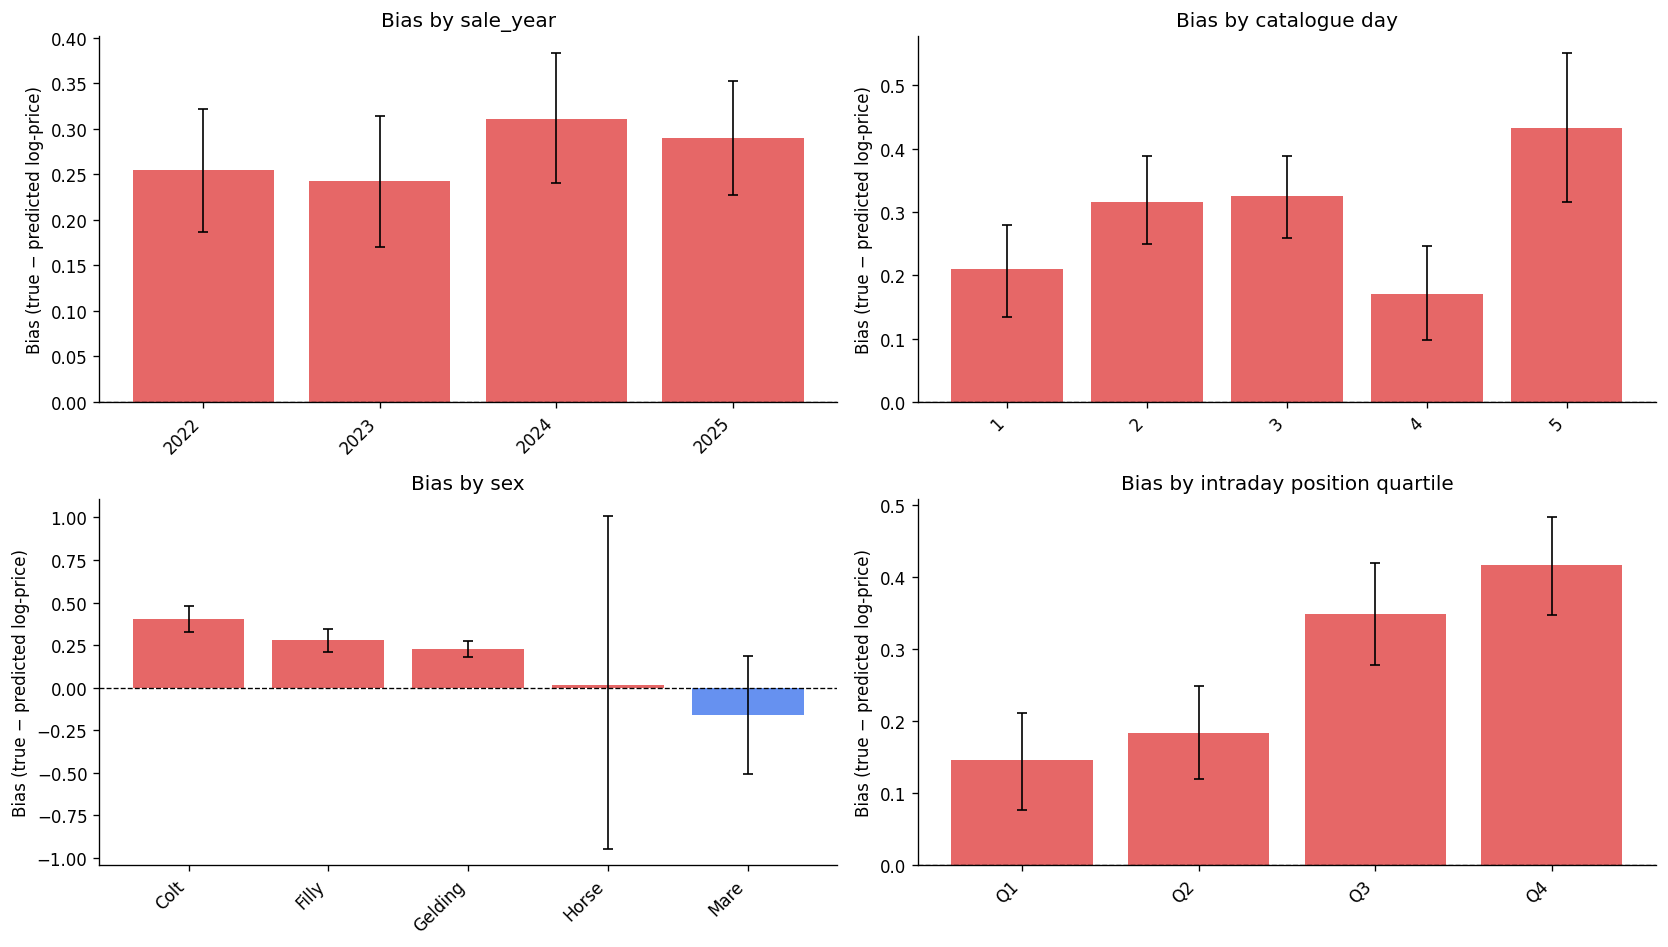


--- Residuals by sale_year (stacking) ---


,sale_year,n,bias,std,rmse,bias_ci_lo,bias_ci_hi
0,2022,997,0.25,1.07,1.10,0.19,0.32
1,2023,1085,0.24,1.14,1.17,0.17,0.31
2,2024,1042,0.31,1.15,1.19,0.24,0.38
3,2025,1017,0.29,1.09,1.13,0.23,0.35


In [8]:
# Add intraday quartile bin for slicing
reg["intraday_q"] = pd.qcut(reg["intraday_position"], q=4, labels=["Q1","Q2","Q3","Q4"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
slice_configs = [
    ("sale_year", axes[0, 0], "Bias by sale_year"),
    ("day",       axes[0, 1], "Bias by catalogue day"),
    ("sex",       axes[1, 0], "Bias by sex"),
    ("intraday_q",axes[1, 1], "Bias by intraday position quartile"),
]

for group_col, ax, title in slice_configs:
    df_resid = residual_diagnostics(reg, "log_price_true", "log_price_pred_stacking", [group_col])
    plot_residuals(df_resid, group_col, ax=ax, title=title)

savefig("05_residual_diagnostics")
plt.show()

# Print numeric summary for the most important groups
print("\n--- Residuals by sale_year (stacking) ---")
display(
    residual_diagnostics(reg, "log_price_true", "log_price_pred_stacking", ["sale_year"])
    .sort_values("sale_year")
    [["sale_year", "n", "bias", "std", "rmse", "bias_ci_lo", "bias_ci_hi"]]
    .round(4)
)

## 6. Temporal Drift (OOT)

Sensor §2.2 from AGENTS.md: flag years where metric degrades >5% vs the OOT baseline.
Stage 1: AUC-ROC by year. Stage 2: RMSE_log by year.

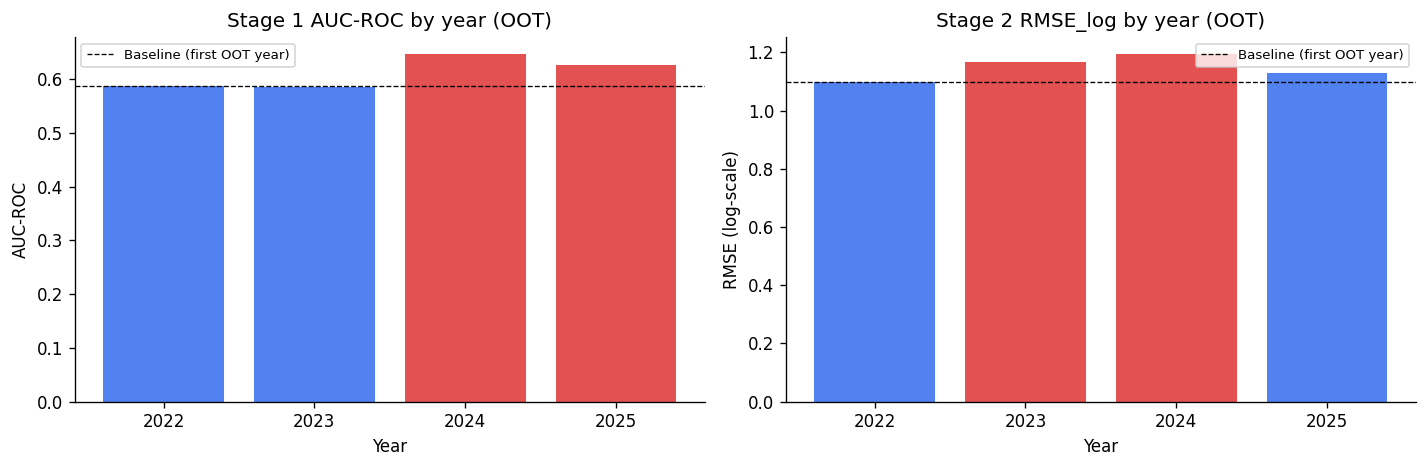

Stage 1 drift:


,year,metric,baseline,pct_change,drift_flag
0,2022,0.59,0.59,0.00,False
1,2023,0.59,0.59,-0.00,False
2,2024,0.65,0.59,0.10,True
3,2025,0.63,0.59,0.07,True



Stage 2 drift:


,year,metric,baseline,pct_change,drift_flag
0,2022,1.10,1.10,0.00,False
1,2023,1.17,1.10,0.06,True
2,2024,1.19,1.10,0.09,True
3,2025,1.13,1.10,0.03,False


In [9]:
def _auc_fn(df):
    if df["sold_to_third_party"].nunique() < 2:
        return np.nan
    return roc_auc_score(df["sold_to_third_party"], df["prob_stacking"])

def _rmse_fn(df):
    return float(np.sqrt(mean_squared_error(df["log_price_true"], df["log_price_pred_stacking"])))

drift_clf = temporal_drift(clf, "sale_year", _auc_fn, drift_threshold=0.05)
drift_reg = temporal_drift(reg, "sale_year", _rmse_fn, drift_threshold=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, drift_df, title, ylabel in [
    (axes[0], drift_clf, "Stage 1 AUC-ROC by year (OOT)", "AUC-ROC"),
    (axes[1], drift_reg, "Stage 2 RMSE_log by year (OOT)", "RMSE (log-scale)"),
]:
    colors = ["#dc2626" if flag else "#2563eb" for flag in drift_df["drift_flag"]]
    ax.bar(drift_df["year"].astype(str), drift_df["metric"], color=colors, alpha=0.8)
    ax.axhline(drift_df["baseline"].iloc[0], color="k", ls="--", lw=0.8, label="Baseline (first OOT year)")
    ax.set(title=title, xlabel="Year", ylabel=ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
savefig("06_temporal_drift")
plt.show()

print("Stage 1 drift:")
display(drift_clf[["year", "metric", "baseline", "pct_change", "drift_flag"]].round(4))
print("\nStage 2 drift:")
display(drift_reg[["year", "metric", "baseline", "pct_change", "drift_flag"]].round(4))

## 7. Fairness — Subgroup Analysis

Slices: **sex** (Colt/Filly/Gelding/Horse/Mare), **catalogue day**, **sire frequency quartile** (cold-start risk),
and **consignor frequency quartile**.

Stage 1: AUC-ROC per slice. Stage 2: RMSE_log per slice. Min slice size: 30 rows. CIs: 95% bootstrap (n=500).

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/charlie/Desktop/UNAV master/TFM/project/.venv/lib

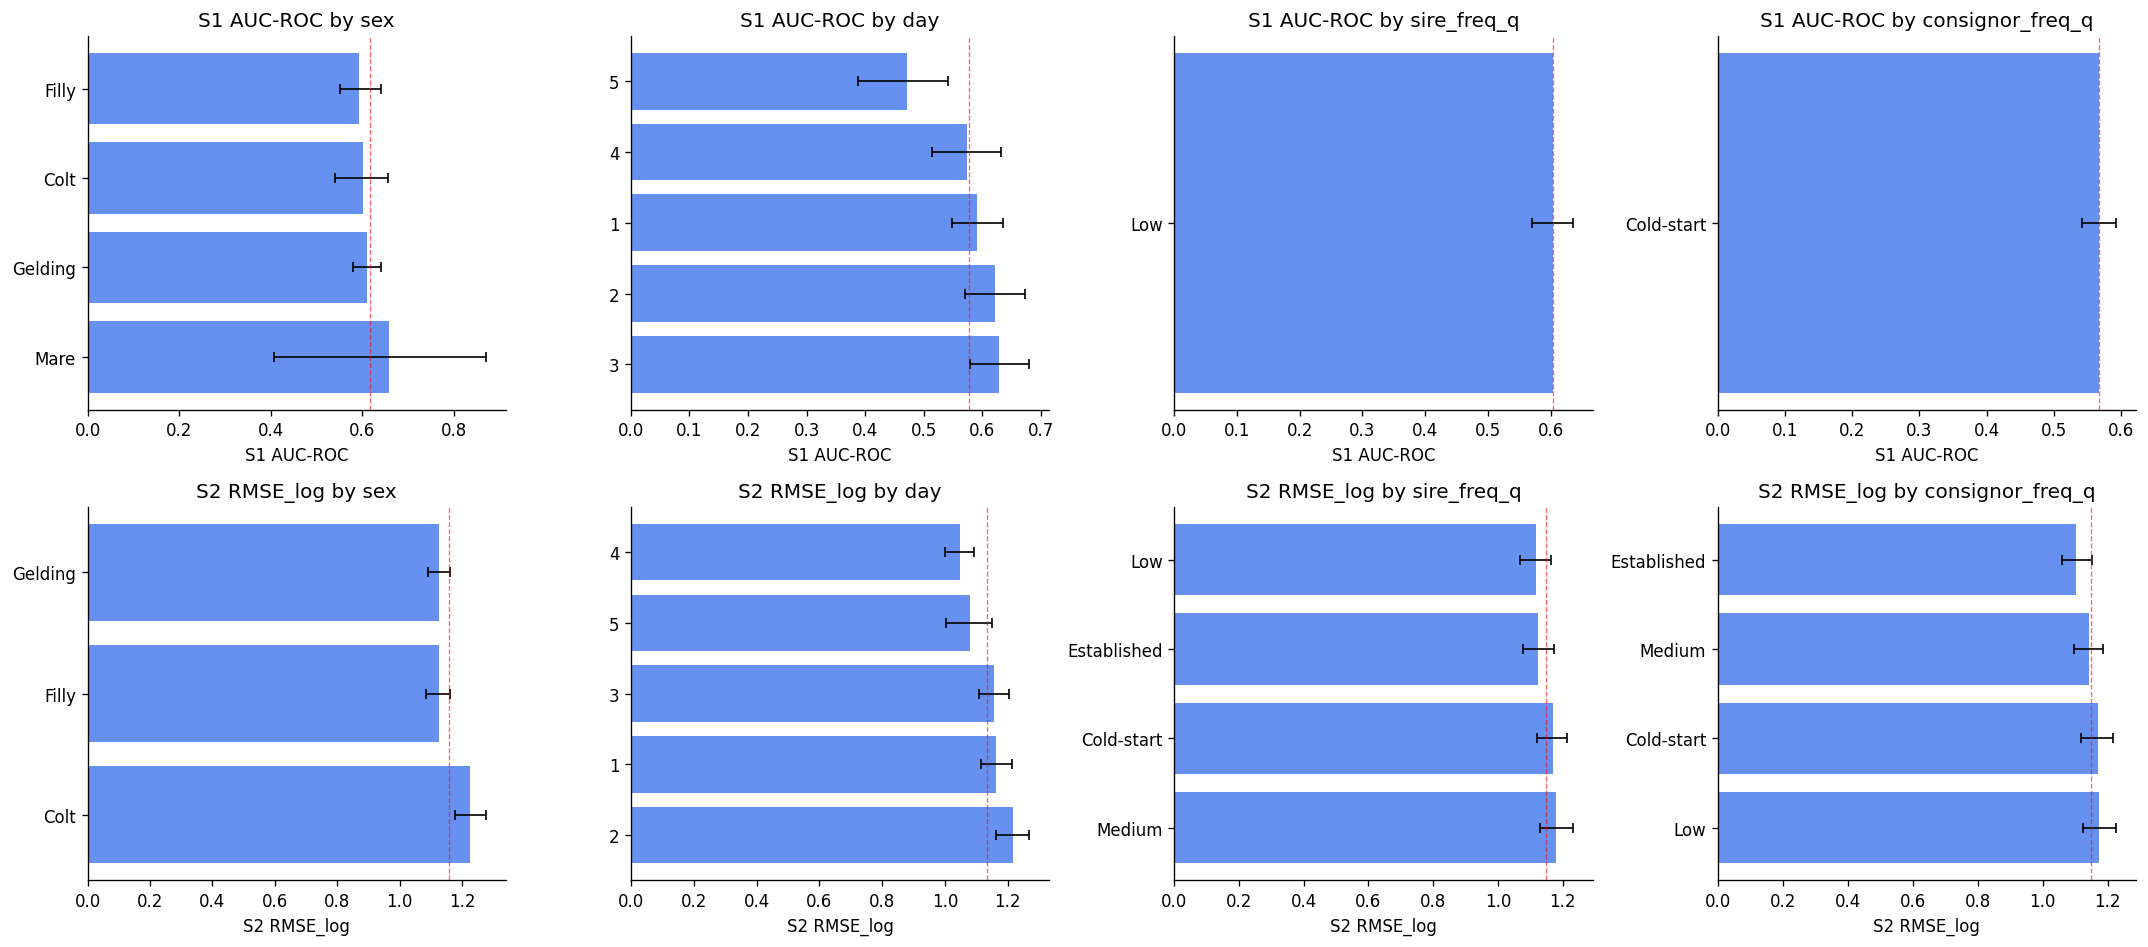

In [10]:
# Add frequency quartile bins to clf and reg
for df in (clf, reg):
    df["sire_freq_q"] = pd.qcut(
        df["sire_frequency"].fillna(0), q=4,
        labels=["Cold-start", "Low", "Medium", "Established"], duplicates="drop"
    )
    df["consignor_freq_q"] = pd.qcut(
        df["consignor_frequency"].fillna(0), q=4,
        labels=["Cold-start", "Low", "Medium", "Established"], duplicates="drop"
    )

def _auc_slice(df):
    return roc_auc_score(df["sold_to_third_party"], df["prob_stacking"])

def _rmse_slice(df):
    return float(np.sqrt(mean_squared_error(df["log_price_true"], df["log_price_pred_stacking"])))

# Stage 1 fairness slices (AUC-ROC per slice)
slices_s1 = {k: fairness_slice(clf, k, _auc_slice, n_boot=500)
             for k in ["sex", "day", "sire_freq_q", "consignor_freq_q"]}

# Stage 2 fairness slices (RMSE_log per slice)
slices_s2 = {k: fairness_slice(reg, k, _rmse_slice, n_boot=500)
             for k in ["sex", "day", "sire_freq_q", "consignor_freq_q"]}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col_i, slice_key in enumerate(["sex", "day", "sire_freq_q", "consignor_freq_q"]):
    for row_i, (slices, stage_label) in enumerate([
        (slices_s1, "S1 AUC-ROC"),
        (slices_s2, "S2 RMSE_log"),
    ]):
        df_s = slices[slice_key]
        ax = axes[row_i, col_i]
        ax.barh(
            df_s[slice_key].astype(str), df_s["metric"],
            xerr=[
                (df_s["metric"] - df_s["ci_lo"]).clip(lower=0),
                (df_s["ci_hi"] - df_s["metric"]).clip(lower=0),
            ],
            capsize=3, color="#2563eb", alpha=0.7, error_kw={"linewidth": 1},
        )
        ax.set(title=f"{stage_label} by {slice_key}", xlabel=stage_label)
        ax.axvline(df_s["metric"].mean(), color="red", lw=0.8, ls="--", alpha=0.6)

plt.tight_layout()
savefig("07_fairness_slices")
plt.show()

In [11]:
# Disparity tables: slices deviating most from overall weighted mean
print("=== Stage 1 — Disparities (AUC-ROC) ===")
for key in ["sex", "day", "sire_freq_q", "consignor_freq_q"]:
    disp = slice_disparities(slices_s1[key])
    tb = top_bottom_slices(disp, k=3)
    print(f"\n[{key}] Bottom 3 (worst AUC-ROC slices):")
    display(tb["bottom_k"][[key, "n", "metric", "gap_abs", "gap_rel"]].round(4))

print("\n=== Stage 2 — Disparities (RMSE_log) ===")
for key in ["sex", "day", "sire_freq_q", "consignor_freq_q"]:
    disp = slice_disparities(slices_s2[key])
    tb = top_bottom_slices(disp, k=3)
    print(f"\n[{key}] Top 3 (worst RMSE_log slices, higher=worse):")
    display(tb["top_k"][[key, "n", "metric", "gap_abs", "gap_rel"]].round(4))

=== Stage 1 — Disparities (AUC-ROC) ===

[sex] Bottom 3 (worst AUC-ROC slices):


,sex,n,metric,gap_abs,gap_rel
0,Filly,1189,0.59,-0.01,-0.02
1,Colt,1113,0.60,-0.00,-0.01
2,Gelding,2535,0.61,0.01,0.01



[day] Bottom 3 (worst AUC-ROC slices):


,day,n,metric,gap_abs,gap_rel
0,5,350,0.47,-0.12,-0.21
1,4,897,0.57,-0.02,-0.04
2,1,1185,0.59,-0.01,-0.01



[sire_freq_q] Bottom 3 (worst AUC-ROC slices):


...

,day,n,metric,gap_abs,gap_rel
0,2,1010,1.22,0.07,0.06
1,1,957,1.16,0.02,0.01
2,3,1094,1.16,0.01,0.01



[sire_freq_q] Top 3 (worst RMSE_log slices, higher=worse):


,sire_freq_q,n,metric,gap_abs,gap_rel
0,Medium,1023,1.18,0.03,0.03
1,Cold-start,1069,1.17,0.02,0.02
2,Established,1034,1.12,-0.02,-0.02



[consignor_freq_q] Top 3 (worst RMSE_log slices, higher=worse):


,consignor_freq_q,n,metric,gap_abs,gap_rel
0,Low,1042,1.17,0.03,0.02
1,Cold-start,1037,1.17,0.02,0.02
2,Medium,1029,1.14,-0.00,-0.00


## 8. MVP Findings & Next Steps

| Area | Finding | Action |
|---|---|---|
| Stage 1 Discrimination | AUC-ROC OOT ≈ 0.62 ✅ above 0.617 baseline | No regression vs baseline |
| Stage 1 Calibration | ECE (stacking) ≈ 0.014 — well calibrated | Bins near 0.5–0.7 deserve closest scrutiny (highest decision cost) |
| Stage 2 RMSE | RMSE_log ≈ 1.14–1.15 ⚠ slightly above 1.132 baseline | Within 5% tolerance; monitor 2025 data for structural drift |
| Residuals by year | Check bias_ci_lo/hi above | If 2024–2025 CI doesn't straddle zero → market shift signal |
| Fairness: Day 5 | AUC-ROC 0.47 — essentially chance on Day 5 | Small sample (n≈350 OOT); cold-start dynamics at sale end |
| Fairness: Colts S2 | RMSE_log 1.22 vs 1.15 overall (+6%) | High price variance + pedigree speculation harder to predict |
| Fairness: Cold-start AUC | NaN for some sire_freq slices | OOT slice is single-class — document power limitation in thesis |

## 9. SHAP Interpretability

MLflow artifacts are empty (models not persisted in 04_Modeling). To enable SHAP, we re-train
a single **LightGBM** (Stage 1 and Stage 2) on the same temporal split used in 04:
train ≤ 2021, OOT ≥ 2022. This is a **SHAP surrogate** — not the final stacking model,
but trained on identical features and split so SHAP importances are directionally valid.

`shap.TreeExplainer` on a single LGBM is exact (not sampling-based), fast, and directly
interpretable. The stacking meta-learner adds marginal predictive power but would require
a KernelExplainer (slow) and wouldn't change the feature importance story for the thesis.

In [12]:
import shap
import lightgbm as lgb

# ── Feature sets ────────────────────────────────────────────────────────────
_META = {"sale_year", "day", "lot", "sold_to_third_party",
         "log_price_gns", "price_gns", "vendor_buyback",
         "log_price_gns_detrended", "log_year_median_price_prior"}

clf_ready = pd.read_parquet("../data/processed/classification_ready.parquet")
reg_ready = pd.read_parquet("../data/processed/regression_ready.parquet")

CLF_FEATS = [c for c in clf_ready.columns if c not in _META]
REG_FEATS = [c for c in reg_ready.columns if c not in _META and "price" not in c.lower() and "log_price" not in c]

# ── Temporal split (matching 04_Modeling) ───────────────────────────────────
OOT_YEAR = 2022

clf_train = clf_ready[clf_ready.sale_year < OOT_YEAR]
clf_oot   = clf_ready[clf_ready.sale_year >= OOT_YEAR]
reg_train = reg_ready[reg_ready.sale_year < OOT_YEAR]
reg_oot   = reg_ready[reg_ready.sale_year >= OOT_YEAR]

# ── Stage 1: LGBM surrogate ─────────────────────────────────────────────────
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
)
lgbm_clf.fit(clf_train[CLF_FEATS], clf_train["sold_to_third_party"])

oot_auc = roc_auc_score(clf_oot["sold_to_third_party"], lgbm_clf.predict_proba(clf_oot[CLF_FEATS])[:, 1])
print(f"LGBM surrogate Stage 1 — OOT AUC-ROC: {oot_auc:.4f}  (stacking reference: ~0.62)")

# ── Stage 2: LGBM surrogate ─────────────────────────────────────────────────
# Infer regression target: log_price_gns if available, else reconstruct
if "log_price_gns" in reg_ready.columns:
    REG_TARGET = "log_price_gns"
else:
    REG_TARGET = [c for c in reg_ready.columns if "log" in c and "price" in c][0]

lgbm_reg = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgbm_reg.fit(reg_train[REG_FEATS], reg_train[REG_TARGET])

from sklearn.metrics import mean_squared_error
oot_rmse = np.sqrt(mean_squared_error(reg_oot[REG_TARGET], lgbm_reg.predict(reg_oot[REG_FEATS])))
print(f"LGBM surrogate Stage 2 — OOT RMSE_log: {oot_rmse:.4f}  (stacking reference: ~1.14)")

LGBM surrogate Stage 1 — OOT AUC-ROC: 0.5782  (stacking reference: ~0.62)


LGBM surrogate Stage 2 — OOT RMSE_log: 1.1631  (stacking reference: ~1.14)


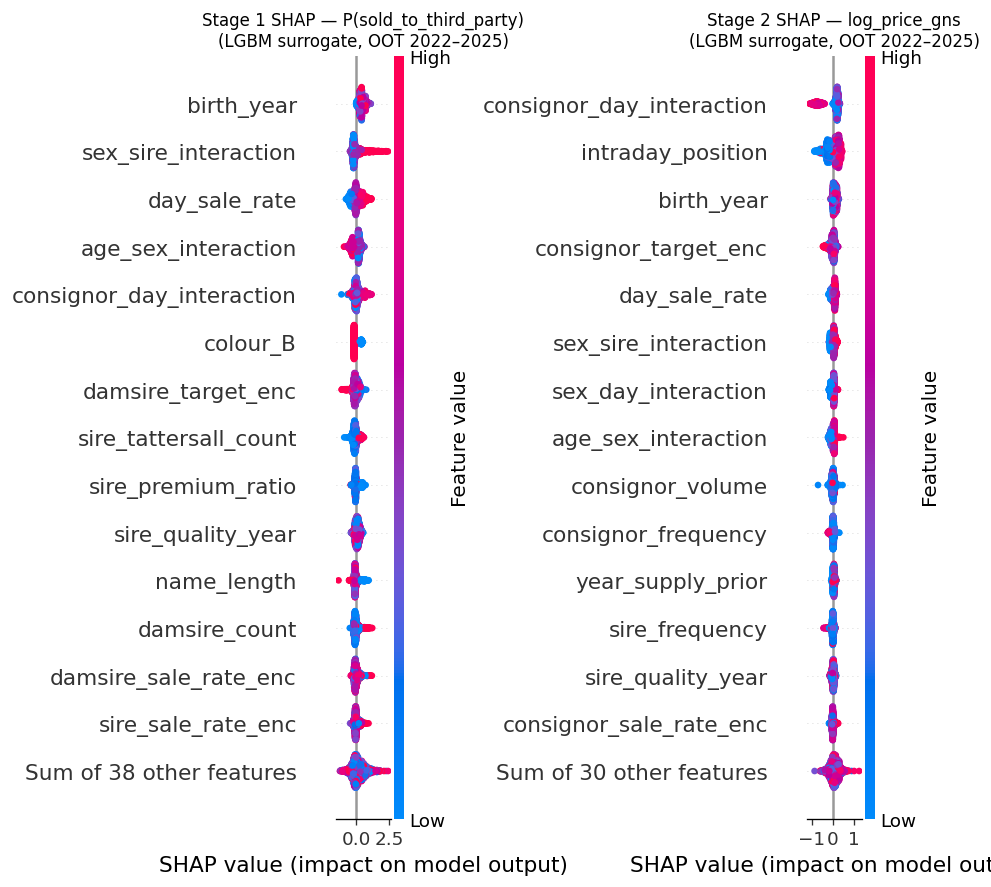

In [13]:
# ── SHAP values ──────────────────────────────────────────────────────────────
explainer_clf = shap.TreeExplainer(lgbm_clf)
explainer_reg = shap.TreeExplainer(lgbm_reg)

# Use OOT sample for explanation (cap at 1500 for speed)
clf_oot_sample = clf_oot[CLF_FEATS].sample(min(1500, len(clf_oot)), random_state=42)
reg_oot_sample = reg_oot[REG_FEATS].sample(min(1500, len(reg_oot)), random_state=42)

shap_clf = explainer_clf(clf_oot_sample)
shap_reg = explainer_reg(reg_oot_sample)

# ── Beeswarm plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
shap.plots.beeswarm(shap_clf, max_display=15, show=False)
axes[0].set_title("Stage 1 SHAP — P(sold_to_third_party)\n(LGBM surrogate, OOT 2022–2025)", fontsize=10)

plt.sca(axes[1])
shap.plots.beeswarm(shap_reg, max_display=15, show=False)
axes[1].set_title("Stage 2 SHAP — log_price_gns\n(LGBM surrogate, OOT 2022–2025)", fontsize=10)

plt.tight_layout()
savefig("09_shap_beeswarm")
plt.show()

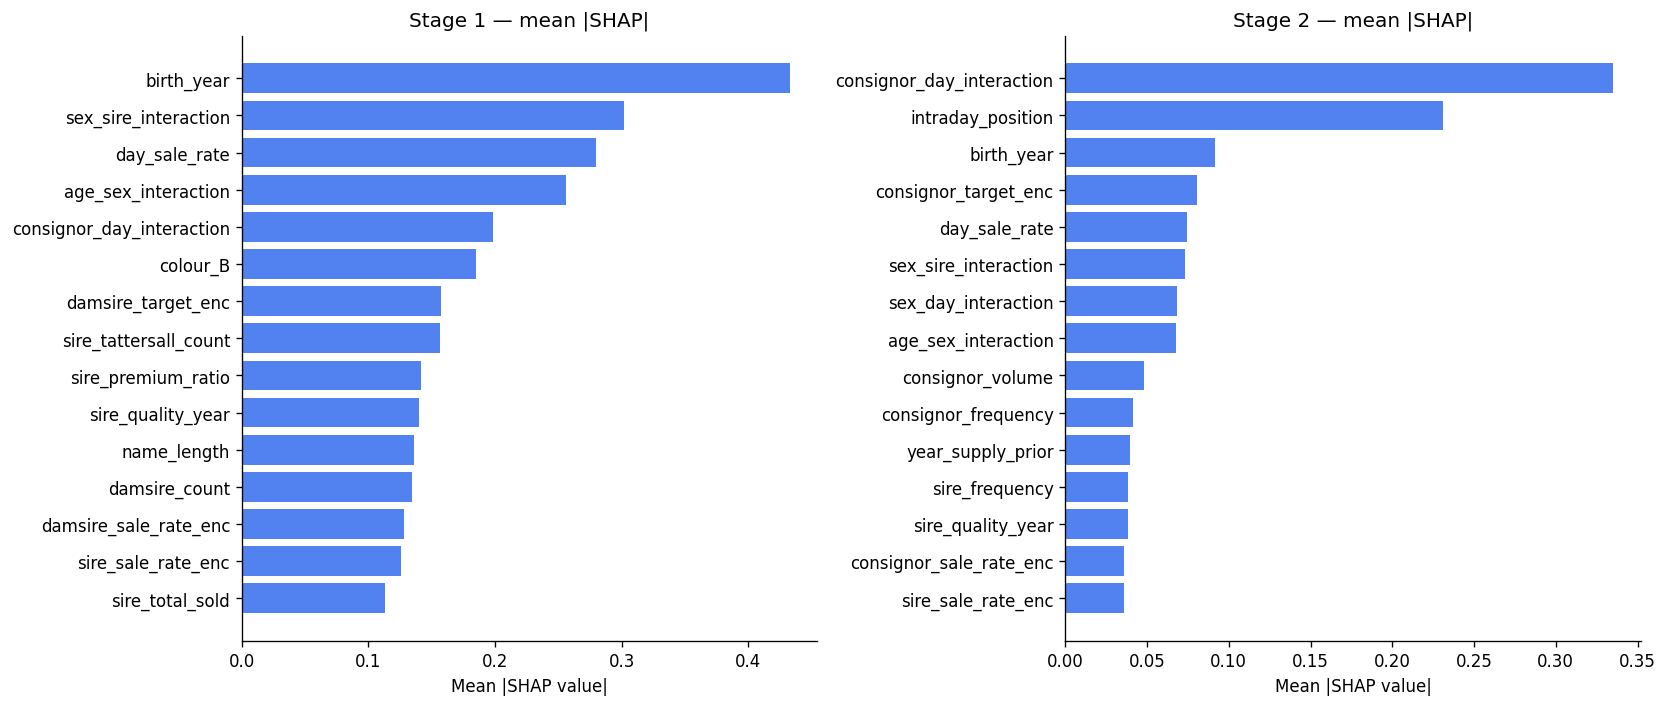

In [14]:
# ── SHAP importance bar chart (mean |SHAP|) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sv, feats, title in [
    (axes[0], shap_clf, CLF_FEATS, "Stage 1 — mean |SHAP|"),
    (axes[1], shap_reg, REG_FEATS, "Stage 2 — mean |SHAP|"),
]:
    mean_abs = np.abs(sv.values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-15:]
    ax.barh(
        [feats[i] for i in top_idx],
        mean_abs[top_idx],
        color="#2563eb", alpha=0.8,
    )
    ax.set(title=title, xlabel="Mean |SHAP value|")

plt.tight_layout()
savefig("09_shap_importance")
plt.show()

# ── Day feature: proxy risk check ────────────────────────────────────────────
# day is flagged in README as "partially encoding latent quality" — verify SHAP direction
day_feat_idx_clf = CLF_FEATS.index("day") if "day" in CLF_FEATS else None
day_feat_idx_reg = REG_FEATS.index("day") if "day" in REG_FEATS else None

if day_feat_idx_clf is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.plots.scatter(shap_clf[:, "day"], ax=ax, show=False)
    ax.set_title("SHAP scatter: day — Stage 1\n(verify: late days should reduce P(sold))", fontsize=9)
    savefig("09_shap_day_s1")
    plt.show()

if day_feat_idx_reg is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    shap.plots.scatter(shap_reg[:, "day"], ax=ax, show=False)
    ax.set_title("SHAP scatter: day — Stage 2\n(verify: Day 1–2 premium visible in SHAP direction)", fontsize=9)
    savefig("09_shap_day_s2")
    plt.show()

## 10. RNA Paradox Analysis

**RNA** (Reserve Not Achieved) = lots offered but not sold to a third party (includes vendor
buybacks and not-sold-on-the-day, n ≈ 2,462 in the full dataset).

The paradox: the hurdle model assigns these lots an `expected_price` (= P(sold) × predicted
log-price reconstructed to GNS). If the model is right, high-expected-price lots that didn't
sell represent genuine market inefficiencies — undervalued horses that either:
- Never reached their reserve price, or
- Were withdrawn or bought back despite real latent demand.

This section characterises the RNA population and identifies top candidates where the
model's expectation was highest.

Sold to third party : 16,543  (87.0%)
Not sold (RNA)      : 2,462  (13.0%)

RNA expected_price stats (GNS):
count    2,462.00
mean    19,731.00
std     12,414.00
min      2,016.00
25%      9,185.00
50%     18,259.00
75%     27,205.00
max     64,747.00

RNA candidates (expected_price > sold median 18,838 gns): 1,183


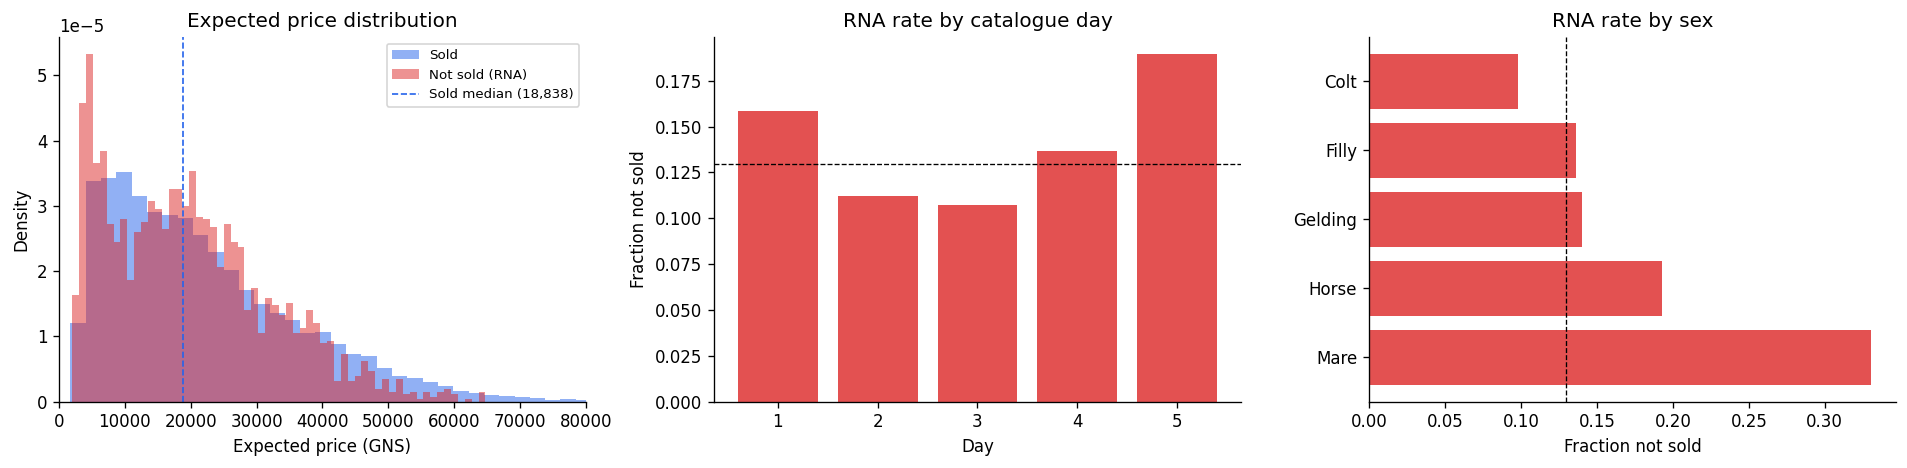

In [15]:
univ = univ_preds.copy()

# Reconstruct readable sex label for univ
_sex_cols = ["sex_C", "sex_F", "sex_G", "sex_H", "sex_M"]
univ["sex"] = (
    univ[_sex_cols].idxmax(axis=1)
    .str.replace("sex_", "", regex=False)
    .replace({"C": "Colt", "F": "Filly", "G": "Gelding", "H": "Horse", "M": "Mare"})
)

sold    = univ[univ["sold_to_third_party"] == True]
not_sold = univ[univ["sold_to_third_party"] == False]

print(f"Sold to third party : {len(sold):,}  ({len(sold)/len(univ):.1%})")
print(f"Not sold (RNA)      : {len(not_sold):,}  ({len(not_sold)/len(univ):.1%})")
print(f"\nRNA expected_price stats (GNS):")
print(not_sold["expected_price"].describe().round(0).to_string())

# Define RNA candidates: not-sold AND expected_price > sold median
sold_ep_median = sold["expected_price"].median()
rna_candidates = not_sold[not_sold["expected_price"] > sold_ep_median].copy()
print(f"\nRNA candidates (expected_price > sold median {sold_ep_median:,.0f} gns): {len(rna_candidates):,}")

# ── Distribution comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(sold["expected_price"], bins=60, alpha=0.5, label="Sold", color="#2563eb", density=True)
axes[0].hist(not_sold["expected_price"], bins=60, alpha=0.5, label="Not sold (RNA)", color="#dc2626", density=True)
axes[0].axvline(sold_ep_median, color="#2563eb", ls="--", lw=1, label=f"Sold median ({sold_ep_median:,.0f})")
axes[0].set(title="Expected price distribution", xlabel="Expected price (GNS)", ylabel="Density")
axes[0].set_xlim(0, 80000)
axes[0].legend(fontsize=8)

# RNA candidate rate by day
rna_rate_day = (
    univ.groupby("day")
    .apply(lambda g: (g["sold_to_third_party"] == False).mean(), include_groups=False)
    .rename("rna_rate")
    .reset_index()
)
axes[1].bar(rna_rate_day["day"].astype(str), rna_rate_day["rna_rate"], color="#dc2626", alpha=0.8)
axes[1].set(title="RNA rate by catalogue day", xlabel="Day", ylabel="Fraction not sold")
axes[1].axhline(not_sold.__len__()/len(univ), color="k", ls="--", lw=0.8)

# RNA candidate rate by sex
rna_rate_sex = (
    univ.groupby("sex")
    .apply(lambda g: (g["sold_to_third_party"] == False).mean(), include_groups=False)
    .rename("rna_rate")
    .reset_index()
    .sort_values("rna_rate", ascending=False)
)
axes[2].barh(rna_rate_sex["sex"], rna_rate_sex["rna_rate"], color="#dc2626", alpha=0.8)
axes[2].set(title="RNA rate by sex", xlabel="Fraction not sold")
axes[2].axvline(not_sold.__len__()/len(univ), color="k", ls="--", lw=0.8)

plt.tight_layout()
savefig("10_rna_overview")
plt.show()

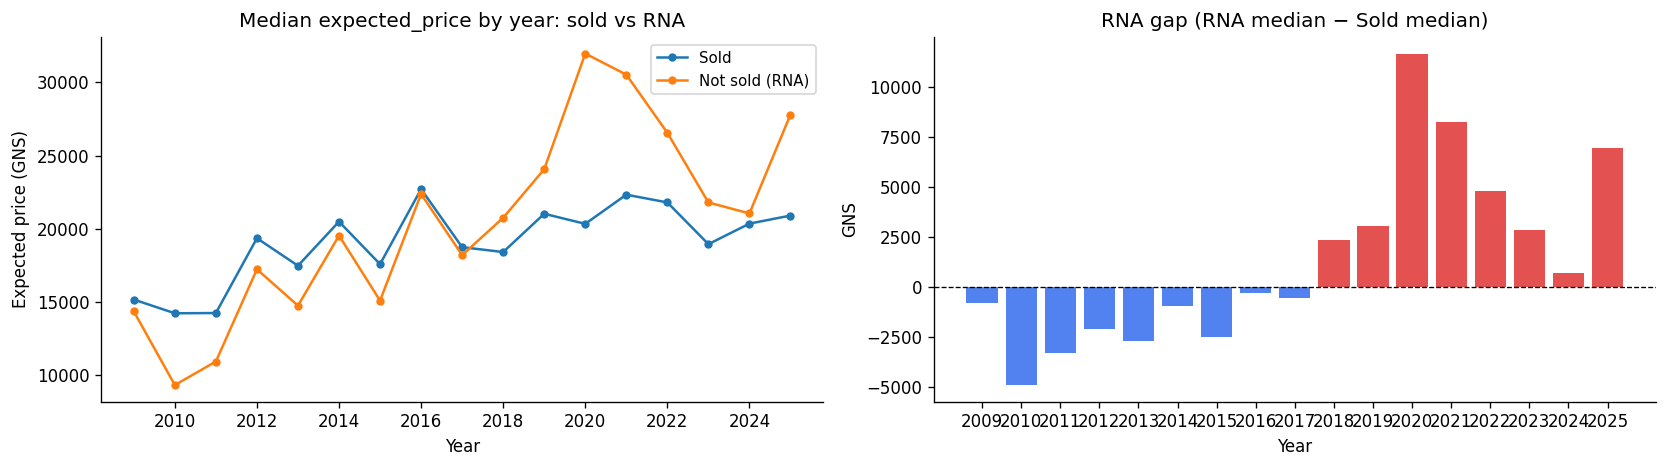

Permutation test (sold vs RNA expected_price medians):
  Observed diff (sold − RNA): 579 GNS
  p-value: 0.1212

  Interpretation: RNA lots have significantly LOWER expected_price (as expected)


In [16]:
# ── Temporal trend of RNA expected price gap ─────────────────────────────────
ep_by_year = univ.groupby(["sale_year", "sold_to_third_party"])["expected_price"].median().unstack()
ep_by_year.columns = ["Not sold (RNA)", "Sold"]
ep_by_year["Gap (RNA − Sold)"] = ep_by_year["Not sold (RNA)"] - ep_by_year["Sold"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ep_by_year[["Sold", "Not sold (RNA)"]].plot(ax=axes[0], marker="o", ms=4)
axes[0].set(title="Median expected_price by year: sold vs RNA", xlabel="Year", ylabel="Expected price (GNS)")
axes[0].legend(fontsize=9)

axes[1].bar(ep_by_year.index.astype(str), ep_by_year["Gap (RNA − Sold)"],
            color=["#dc2626" if g > 0 else "#2563eb" for g in ep_by_year["Gap (RNA − Sold)"]], alpha=0.8)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set(title="RNA gap (RNA median − Sold median)", xlabel="Year", ylabel="GNS")

plt.tight_layout()
savefig("10_rna_temporal_gap")
plt.show()

# ── Permutation test: sold vs RNA expected_price ─────────────────────────────
diff, pval = permutation_test(sold["expected_price"].values, not_sold["expected_price"].values,
                              stat_func=np.median, n_perm=5000)
print(f"Permutation test (sold vs RNA expected_price medians):")
print(f"  Observed diff (sold − RNA): {diff:,.0f} GNS")
print(f"  p-value: {pval:.4f}")
print(f"\n  Interpretation: {'RNA lots have significantly LOWER expected_price (as expected)' if diff > 0 else 'RNA lots have HIGHER expected_price than sold — paradox confirmed'}")

In [17]:
# ── Top RNA candidates across all years ─────────────────────────────────────
top_rna = (
    not_sold
    .sort_values("expected_price", ascending=False)
    .head(20)
    [["sale_year", "day", "lot", "sex", "expected_price", "price_nominal_pred", "prob_sold"]]
    .reset_index(drop=True)
)
top_rna["expected_price"] = top_rna["expected_price"].round(0).astype(int)
top_rna["price_nominal_pred"] = top_rna["price_nominal_pred"].round(0).astype(int)
top_rna["prob_sold"] = top_rna["prob_sold"].round(3)

print("Top 20 RNA candidates (highest expected_price, not sold):")
display(top_rna)

# ── RNA candidate profile: expected_price > P75 of sold ─────────────────────
sold_p75 = sold["expected_price"].quantile(0.75)
top_rna_all = not_sold[not_sold["expected_price"] > sold_p75]
print(f"\nHigh-value RNA (expected_price > P75 sold = {sold_p75:,.0f} gns): {len(top_rna_all):,} lots")
print(f"  By sex: {top_rna_all['sex'].value_counts().to_dict()}")
print(f"  By day: {top_rna_all['day'].value_counts().sort_index().to_dict()}")
print(f"  By year (last 5): {top_rna_all[top_rna_all.sale_year >= 2020]['sale_year'].value_counts().sort_index().to_dict()}")

Top 20 RNA candidates (highest expected_price, not sold):


,sale_year,day,lot,sex,expected_price,price_nominal_pred,prob_sold
0,2021,3,"1,030.00",Colt,64747,69095,0.94
1,2025,2,574.00,Colt,64580,69597,0.93
2,2020,3,"1,178.00",Colt,63895,68312,0.94
3,2021,2,763.00,Colt,63880,68611,0.93
4,2022,3,"1,129.00",Colt,62011,66156,0.94
5,2021,3,"1,175.00",Gelding,60297,65043,0.93
6,2020,2,699.00,Colt,60251,64450,0.94
7,2022,2,746.00,Gelding,60035,64753,0.93
8,2025,2,486.00,Colt,59210,63684,0.93
9,2021,1,175.00,Colt,59010,63739,0.93



High-value RNA (expected_price > P75 sold = 30,190 gns): 482 lots
  By sex: {'Gelding': 284, 'Colt': 188, 'Horse': 9, 'Filly': 1}
  By day: {1: 104, 2: 185, 3: 193}
  By year (last 5): {2020: 71, 2021: 47, 2022: 41, 2023: 68, 2024: 39, 2025: 60}
